#Data preparation and cleaning

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
data='https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'

In [ ]:
!wget $data

--2026-02-25 18:28:12--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv’

CreditScoring.csv   100%[===================>] 178.21K  --.-KB/s    in 0.005s  

2026-02-25 18:28:14 (38.1 MB/s) - ‘CreditScoring.csv’ saved [182489/182489]



In [ ]:

!head CreditScoring.csv

"Status","Seniority","Home","Time","Age","Marital","Records","Job","Expenses","Income","Assets","Debt","Amount","Price"
1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
1,0,1,36,26,1,1,1,46,107,0,0,310,910
1,1,2,60,36,2,1,1,75,214,3500,0,650,1645
1,29,2,60,44,2,1,1,75,125,10000,0,1600,1800
1,9,5,12,27,1,1,1,35,80,0,0,200,1093
1,0,2,60,32,2,1,3,90,107,15000,0,1200,1957


In [ ]:
df = pd.read_csv(data)

In [ ]:
df.head()


,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [ ]:
df.describe()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4.455000e+03,4.455000e+03,4.455000e+03,4455.000000,4455.000000
mean,1.281257,7.987205,2.657015,46.441751,37.077666,1.879012,1.173513,1.675870,55.568799,7.633170e+05,1.060341e+06,4.043820e+05,1039.021773,1462.875645
std,0.450162,8.173444,1.610467,14.655225,10.984856,0.643748,0.378733,0.954035,19.515878,8.703625e+06,1.021757e+07,6.344253e+06,474.543007,628.089913
min,0.000000,0.000000,0.000000,6.000000,18.000000,0.000000,1.000000,0.000000,35.000000,0.000000e+00,0.000000e+00,0.000000e+00,100.000000,105.000000
25%,1.000000,2.000000,2.000000,36.000000,28.000000,2.000000,1.000000,1.000000,35.000000,8.000000e+01,0.000000e+00,0.000000e+00,700.000000,1117.500000
50%,1.000000,5.000000,2.000000,48.000000,36.000000,2.000000,1.000000,1.000000,51.000000,1.200000e+02,3.500000e+03,0.000000e+00,1000.000000,1400.000000
75%,2.000000,12.000000,4.000000,60.000000,45.000000,2.000000,1.000000,3.000000,72.000000,1.660000e+02,6.000000e+03,0.000000e+00,1300.000000,1692.000000
max,2.000000,48.000000,6.000000,72.000000,68.000000,5.000000,2.000000,4.000000,180.000000,1.000000e+08,1.000000e+08,1.000000e+08,5000.000000,11140.000000


In [ ]:
df.columns=df.columns.str.lower()
df.columns

Index(['status', 'seniority', 'home', 'time', 'age', 'marital', 'records',
       'job', 'expenses', 'income', 'assets', 'debt', 'amount', 'price'],
      dtype='object')

In [ ]:
status_values={1:'ok',
2:'default',
0:'unk'}
df.status=df.status.map(status_values)


In [ ]:
df.head()


,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [ ]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [ ]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [ ]:
df.describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4.455000e+03,4.455000e+03,4.455000e+03,4455.000000,4455.000000
mean,7.987205,46.441751,37.077666,55.568799,7.633170e+05,1.060341e+06,4.043820e+05,1039.021773,1462.875645
std,8.173444,14.655225,10.984856,19.515878,8.703625e+06,1.021757e+07,6.344253e+06,474.543007,628.089913
min,0.000000,6.000000,18.000000,35.000000,0.000000e+00,0.000000e+00,0.000000e+00,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,8.000000e+01,0.000000e+00,0.000000e+00,700.000000,1117.500000
50%,5.000000,48.000000,36.000000,51.000000,1.200000e+02,3.500000e+03,0.000000e+00,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,1.660000e+02,6.000000e+03,0.000000e+00,1300.000000,1692.000000
max,48.000000,72.000000,68.000000,180.000000,1.000000e+08,1.000000e+08,1.000000e+08,5000.000000,11140.000000


In [ ]:
df.isnull().sum()

,0
status,0
seniority,0
home,0
time,0
age,0
marital,0
records,0
job,0
expenses,0
income,0


In [ ]:
for c in ['income','assets','debt']:
  df[c]=df[c].replace(to_replace=	1.000000e+08,value=np.nan)

In [ ]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [ ]:
df.describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4.455000e+03,4.455000e+03,4.455000e+03,4455.000000,4455.000000
mean,7.987205,46.441751,37.077666,55.568799,7.633170e+05,1.060341e+06,4.043820e+05,1039.021773,1462.875645
std,8.173444,14.655225,10.984856,19.515878,8.703625e+06,1.021757e+07,6.344253e+06,474.543007,628.089913
min,0.000000,6.000000,18.000000,35.000000,0.000000e+00,0.000000e+00,0.000000e+00,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,8.000000e+01,0.000000e+00,0.000000e+00,700.000000,1117.500000
50%,5.000000,48.000000,36.000000,51.000000,1.200000e+02,3.500000e+03,0.000000e+00,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,1.660000e+02,6.000000e+03,0.000000e+00,1300.000000,1692.000000
max,48.000000,72.000000,68.000000,180.000000,1.000000e+08,1.000000e+08,1.000000e+08,5000.000000,11140.000000


In [ ]:
df.isnull().sum()

,0
status,0
seniority,0
home,0
time,0
age,0
marital,0
records,0
job,0
expenses,0
income,0


In [ ]:
df=df[df.status!='unk'].reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split
df_full_train,df_test=train_test_split(df,test_size=0.2,random_state=11)
df_train,df_val=train_test_split(df_full_train,test_size=0.25,random_state=11)

In [ ]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)


In [ ]:
y_train=(df_train.status=='default').astype(int).values
y_train
y_val=(df_val.status=='default').astype(int).values
y_val
y_test=(df_test.status=='default').astype(int).values
y_test

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,

In [ ]:
del df_train['status']
del df_val['status']
del df_test['status']

In [ ]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0,10000,0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85,0,0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121,0,0,1320,1600
3,1,parents,48,23,single,no,partime,35,72,0,0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100,4000,0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220,20000,0,800,1600
2668,7,private,60,29,married,no,fixed,60,51,3500,500,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28,0,0,400,600
2670,15,owner,48,43,married,no,freelance,60,100,18000,0,2500,2976


#Decision Trees

In [ ]:
def asses_risk(client):
  if client['records']=='yes':
    if client['job']=='yes':
      return 'default'
    else:
      return 'ok'
  else:
    if client['assets']>6000:
      return 'ok'
    else:
      return 'default'

In [ ]:
xi=df_train.iloc[0].to_dict()
xi

{'seniority': 10,
 'home': 'owner',
 'time': 36,
 'age': 36,
 'marital': 'married',
 'records': 'no',
 'job': 'freelance',
 'expenses': 75,
 'income': 0,
 'assets': 10000,
 'debt': 0,
 'amount': 1000,
 'price': 1400}

In [ ]:
asses_risk(xi)

'ok'

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [ ]:
train_dicts=df_train.fillna(0).to_dict(orient='records')
train_dicts

[{'seniority': 10,
  'home': 'owner',
  'time': 36,
  'age': 36,
  'marital': 'married',
  'records': 'no',
  'job': 'freelance',
  'expenses': 75,
  'income': 0,
  'assets': 10000,
  'debt': 0,
  'amount': 1000,
  'price': 1400},
 {'seniority': 6,
  'home': 'parents',
  'time': 48,
  'age': 32,
  'marital': 'single',
  'records': 'yes',
  'job': 'fixed',
  'expenses': 35,
  'income': 85,
  'assets': 0,
  'debt': 0,
  'amount': 1100,
  'price': 1330},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 40,
  'marital': 'married',
  'records': 'no',
  'job': 'fixed',
  'expenses': 75,
  'income': 121,
  'assets': 0,
  'debt': 0,
  'amount': 1320,
  'price': 1600},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 23,
  'marital': 'single',
  'records': 'no',
  'job': 'partime',
  'expenses': 35,
  'income': 72,
  'assets': 0,
  'debt': 0,
  'amount': 1078,
  'price': 1079},
 {'seniority': 5,
  'home': 'owner',
  'time': 36,
  'age': 46,
  'marital': 'married',
  'r

In [ ]:
dv=DictVectorizer(sparse=False)
X_train=dv.fit_transform(train_dicts)
X_train

array([[3.60e+01, 1.00e+03, 1.00e+04, ..., 0.00e+00, 1.00e+01, 3.60e+01],
       [3.20e+01, 1.10e+03, 0.00e+00, ..., 1.00e+00, 6.00e+00, 4.80e+01],
       [4.00e+01, 1.32e+03, 0.00e+00, ..., 0.00e+00, 1.00e+00, 4.80e+01],
       ...,
       [1.90e+01, 4.00e+02, 0.00e+00, ..., 0.00e+00, 1.00e+00, 2.40e+01],
       [4.30e+01, 2.50e+03, 1.80e+04, ..., 0.00e+00, 1.50e+01, 4.80e+01],
       [2.70e+01, 4.50e+02, 5.00e+03, ..., 1.00e+00, 1.20e+01, 4.80e+01]])

In [ ]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [ ]:
dt=DecisionTreeClassifier(max_depth=3)
dt.fit(X_train,y_train)


DecisionTreeClassifier(max_depth=3)

In [ ]:
val_dicts=df_val.fillna(0).to_dict(orient='records')
val_dicts

[{'seniority': 6,
  'home': 'rent',
  'time': 36,
  'age': 31,
  'marital': 'separated',
  'records': 'no',
  'job': 'fixed',
  'expenses': 49,
  'income': 140,
  'assets': 0,
  'debt': 0,
  'amount': 550,
  'price': 999},
 {'seniority': 18,
  'home': 'rent',
  'time': 60,
  'age': 38,
  'marital': 'married',
  'records': 'no',
  'job': 'fixed',
  'expenses': 56,
  'income': 108,
  'assets': 0,
  'debt': 0,
  'amount': 1000,
  'price': 1307},
 {'seniority': 17,
  'home': 'rent',
  'time': 24,
  'age': 40,
  'marital': 'married',
  'records': 'yes',
  'job': 'fixed',
  'expenses': 58,
  'income': 128,
  'assets': 0,
  'debt': 0,
  'amount': 700,
  'price': 982},
 {'seniority': 2,
  'home': 'other',
  'time': 48,
  'age': 29,
  'marital': 'married',
  'records': 'no',
  'job': 'fixed',
  'expenses': 75,
  'income': 96,
  'assets': 6000,
  'debt': 3000,
  'amount': 1200,
  'price': 1521},
 {'seniority': 25,
  'home': 'rent',
  'time': 42,
  'age': 61,
  'marital': 'married',
  'records': 

In [ ]:
X_val=dv.transform(val_dicts)
X_val


array([[3.10e+01, 5.50e+02, 0.00e+00, ..., 0.00e+00, 6.00e+00, 3.60e+01],
       [3.80e+01, 1.00e+03, 0.00e+00, ..., 0.00e+00, 1.80e+01, 6.00e+01],
       [4.00e+01, 7.00e+02, 0.00e+00, ..., 1.00e+00, 1.70e+01, 2.40e+01],
       ...,
       [3.60e+01, 3.90e+03, 2.90e+04, ..., 1.00e+00, 2.00e+00, 6.00e+01],
       [2.50e+01, 3.00e+02, 0.00e+00, ..., 1.00e+00, 3.00e+00, 2.40e+01],
       [3.20e+01, 1.55e+03, 6.00e+03, ..., 0.00e+00, 1.50e+01, 6.00e+01]])

In [ ]:
y_pred=dt.predict_proba(X_val)[:,1]
y_pred


array([0.11995028, 0.11995028, 0.27480916, 0.11995028, 0.11995028,
       0.38753388, 0.11995028, 0.76811594, 0.11995028, 0.11995028,
       0.11995028, 0.11995028, 0.11995028, 0.11995028, 0.27480916,
       0.59090909, 0.11995028, 0.65432099, 0.11995028, 0.11995028,
       0.11995028, 0.38753388, 0.11995028, 0.38753388, 0.65432099,
       0.48387097, 0.65432099, 0.11995028, 0.65432099, 0.11995028,
       0.48387097, 0.11995028, 0.11995028, 0.11995028, 0.11995028,
       0.11995028, 0.76811594, 0.65432099, 0.65432099, 0.76811594,
       0.11995028, 0.76811594, 0.11995028, 0.11995028, 0.11995028,
       0.11995028, 0.76811594, 0.11995028, 0.11995028, 0.11995028,
       0.11995028, 0.11995028, 0.11995028, 0.11995028, 0.38753388,
       0.11995028, 0.11995028, 0.38753388, 0.11995028, 0.11995028,
       0.11995028, 0.11995028, 0.27480916, 0.27480916, 0.11995028,
       0.38753388, 0.27480916, 0.11995028, 0.11995028, 0.11995028,
       0.11995028, 0.11995028, 0.11995028, 0.11995028, 0.11995

In [ ]:
roc_auc_score(y_val, y_pred)

np.float64(0.733876631711511)

In [ ]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)
DecisionTreeClassifier(max_depth=2)
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.7706182046081911
val: 0.733876631711511


In [ ]:
from sklearn.tree import export_text

In [ ]:
print(export_text(dt,feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 3750.00
|   |   |   |--- class: 1
|   |   |--- assets >  3750.00
|   |   |   |--- class: 0



In [ ]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [ ]:
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [ ]:
from IPython.display import display

In [ ]:
Ts = [0, 2000, 3000, 4000, 5000, 8000]
for t in Ts:
  df_left = df_example[df_example.assets <= t]
  df_right = df_example[df_example.assets > t]

  display(df_left)
  print(df_left.status.value_counts(normalize=True))
  display(df_right)
  print(df_right.status.value_counts(normalize=True))

,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default


...

status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64


In [ ]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [   0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000,  500, 'ok'],
    [3000, 2000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [ ]:
df_example.sort_values('debt')

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [ ]:
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

In [ ]:
for feature ,t in thresholds.items():
  print(feature)
  print('-------------------')
  for T in Ts:
    df_left = df_example[df_example[feature] <= T]
    df_right = df_example[df_example[feature] > T]

    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))
    print()

  print('-------------------')



assets
-------------------


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64



...

Series([], Name: proportion, dtype: float64)



,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status


Series([], Name: proportion, dtype: float64)

-------------------


#Decision Tree parameters

max_depts,
min_samples_leaf

In [ ]:
scores=[]
for d in [1,2,3,4,5,6, 10,15,20,None]:
  for s in [1, 5, 10, 15, 20, 500, 100, 200]:
      dt=DecisionTreeClassifier(max_depth=d,min_samples_leaf=s)
      dt.fit(X_train,y_train)
      y_pred=dt.predict_proba(X_val)[:,1]
      auc=roc_auc_score(y_val,y_pred)

      scores.append((d,s,auc))
scores

[(1, 1, np.float64(0.6058644740984719)),
 (1, 5, np.float64(0.6058644740984719)),
 (1, 10, np.float64(0.6058644740984719)),
 (1, 15, np.float64(0.6058644740984719)),
 (1, 20, np.float64(0.6058644740984719)),
 (1, 500, np.float64(0.6200715652321329)),
 (1, 100, np.float64(0.6058644740984719)),
 (1, 200, np.float64(0.6058644740984719)),
 (2, 1, np.float64(0.6685264343319367)),
 (2, 5, np.float64(0.6685264343319367)),
 (2, 10, np.float64(0.6685264343319367)),
 (2, 15, np.float64(0.6685264343319367)),
 (2, 20, np.float64(0.6685264343319367)),
 (2, 500, np.float64(0.679140127388535)),
 (2, 100, np.float64(0.6685264343319367)),
 (2, 200, np.float64(0.6688079726816981)),
 (3, 1, np.float64(0.733876631711511)),
 (3, 5, np.float64(0.733876631711511)),
 (3, 10, np.float64(0.733876631711511)),
 (3, 15, np.float64(0.733876631711511)),
 (3, 20, np.float64(0.733876631711511)),
 (3, 500, np.float64(0.679140127388535)),
 (3, 100, np.float64(0.7341823884139401)),
 (3, 200, np.float64(0.7279794628369378

In [ ]:
df_scores=pd.DataFrame(scores,columns=['max_depth','min_samples_leaf','auc'])
df_scores.sort_values(by='auc',ascending=False)

,max_depth,min_samples_leaf,auc
68,20.0,20,0.782153
52,10.0,20,0.780276
76,NaN,20,0.779946
60,15.0,20,0.779680
54,10.0,100,0.779198
...,...,...,...
0,1.0,1,0.605864
6,1.0,100,0.605864
4,1.0,20,0.605864
7,1.0,200,0.605864


In [ ]:
df_scores_pivot=df_scores.pivot(index='min_samples_leaf',columns='max_depth',values='auc')

<Axes: xlabel='max_depth', ylabel='min_samples_leaf'>

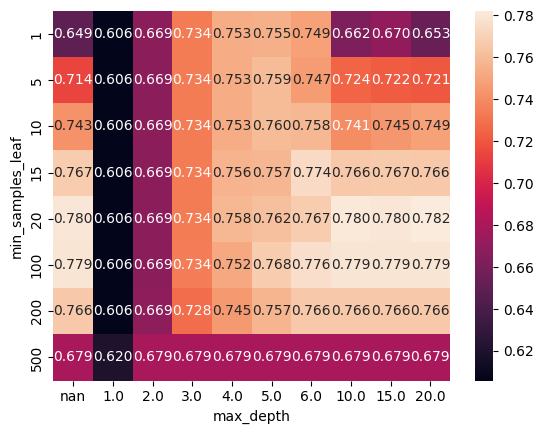

In [ ]:
sns.heatmap(df_scores_pivot,annot=True,fmt='.3f')

In [ ]:
dt=DecisionTreeClassifier(max_depth=6,min_samples_leaf=15)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

#random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf=RandomForestClassifier(n_estimators=10,random_state=1)
rf.fit(X_train,y_train)


RandomForestClassifier(n_estimators=10, random_state=1)

In [ ]:
y_pred=rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val,y_pred)

np.float64(0.7853466857184375)

In [ ]:
rf.predict_proba(X_val[[0]])

array([[1., 0.]])

In [ ]:
scores=[]
for n in range(10,201,10):
  rf=RandomForestClassifier(n_estimators=n,random_state=1)
  rf.fit(X_train,y_train)

  y_pred=rf.predict_proba(X_val)[:,1]
  auc=roc_auc_score(y_val,y_pred)

  scores.append((n,auc))

In [ ]:
df_scores=pd.DataFrame(scores,columns=['n_estimators','auc'])

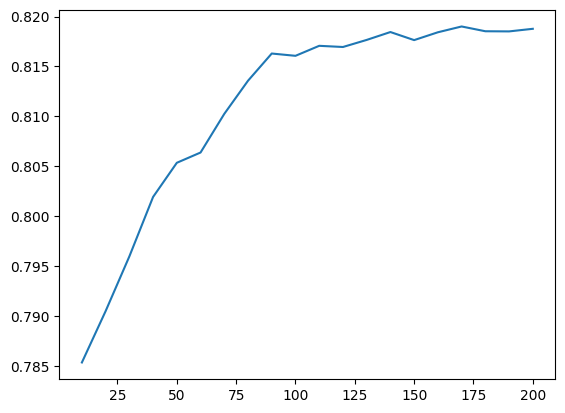

In [ ]:
plt.plot(df_scores.n_estimators,df_scores.auc)

In [ ]:
scores=[]
for d in [5,10,15]:
    for n in range(10,201,10):
      rf=RandomForestClassifier(n_estimators=n,
                                max_depth=d,
                                random_state=1)
      rf.fit(X_train,y_train)

      y_pred=rf.predict_proba(X_val)[:,1]
      auc=roc_auc_score(y_val,y_pred)

      scores.append((d,n,auc))

In [ ]:
df_scores=pd.DataFrame(scores,columns=['max_depth','n_estimator','auc'])
df_scores.head()

,max_depth,n_estimator,auc
0,5,10,0.798624
1,5,20,0.801749
2,5,30,0.802330
3,5,40,0.801706
4,5,50,0.802605


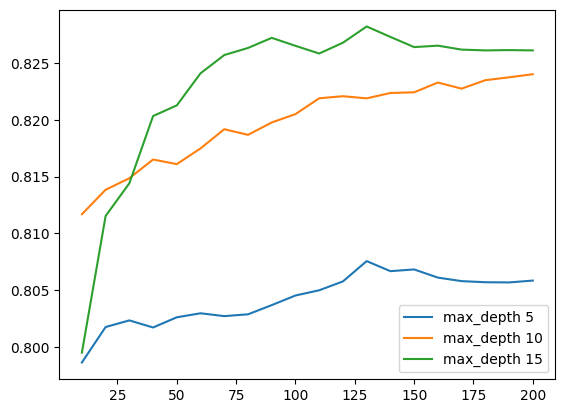

In [ ]:
for d in [5,10,15]:
  df_subset=df_scores[df_scores.max_depth==d]
  plt.plot(df_subset.n_estimator,df_subset.auc,label='max_depth %d'%d)
plt.legend()

In [ ]:
max_depth=10

In [ ]:
scores=[]
for s in [1,3,5,10,50]:
    for n in range(10,201,10):
      rf=RandomForestClassifier(n_estimators=n,
                                max_depth=15,
                                min_samples_leaf=s,
                                random_state=1)
      rf.fit(X_train,y_train)

      y_pred=rf.predict_proba(X_val)[:,1]
      auc=roc_auc_score(y_val,y_pred)

      scores.append((s,n,auc))

In [ ]:
df_scores=pd.DataFrame(scores,columns=['min_samples_leaf','n_estimator','auc'])
df_scores

,min_samples_leaf,n_estimator,auc
0,1,10,0.799490
1,1,20,0.811530
2,1,30,0.814409
3,1,40,0.820330
4,1,50,0.821272
...,...,...,...
95,50,160,0.803822
96,50,170,0.803193
97,50,180,0.802896
98,50,190,0.803526


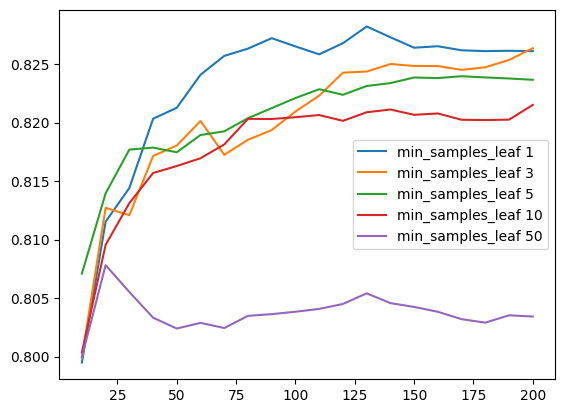

In [ ]:
for s in [1,3,5,10,50]:
  df_subset=df_scores[df_scores.min_samples_leaf==s]
  plt.plot(df_subset.n_estimator,df_subset.auc,label='min_samples_leaf %s'%s)
plt.legend()

In [ ]:
min_samples_leaf=3


In [ ]:
rf=RandomForestClassifier(n_estimators=100,
                                max_depth=15,
                                min_samples_leaf=3,
                                n_jobs=-1,
                                random_state=1)
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=3, n_jobs=-1,
                       random_state=1)

#Gradient Boosting and XGBoost

In [ ]:
!pip install xgboost


In [ ]:
import xgboost as xgb

In [ ]:
features=dv.get_feature_names_out().tolist()
dtrain=xgb.DMatrix(X_train,label=y_train,feature_names=features)
dval=xgb.DMatrix(X_val,label=y_val,feature_names=features)

In [ ]:
xgb_params={
    'eta':0.3,#this how fast our model learns
    'max_depth':6,
    'min_child_weight':1,
    'objective':'binary:logistic',
    'nthread':18,
    'seed':1,
    'verbosity':1
}
model=xgb.train(xgb_params,dtrain,num_boost_round=10)

In [ ]:
y_pred=model.predict(dval)
roc_auc_score(y_val,y_pred)

np.float64(0.8067254365358069)

In [ ]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [ ]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [ ]:
s = output.stdout


In [ ]:
print(s[:200])

[0]	train-auc:0.86379	val-auc:0.77025
[5]	train-auc:0.92346	val-auc:0.80719
[10]	train-auc:0.95075	val-auc:0.81105
[15]	train-auc:0.96165	val-auc:0.81220
[20]	train-auc:0.96988	val-auc:0.81774
[25]	tr


In [ ]:
def parse_xgb_output(output):
  results=[]
  for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

  columns = ['num_iter', 'train_auc', 'val_auc']
  df_results = pd.DataFrame(results, columns=columns)
  return df_results

In [ ]:
df_score = parse_xgb_output(output)
df_score.head()

,num_iter,train_auc,val_auc
0,0,0.86379,0.77025
1,5,0.92346,0.80719
2,10,0.95075,0.81105
3,15,0.96165,0.81220
4,20,0.96988,0.81774


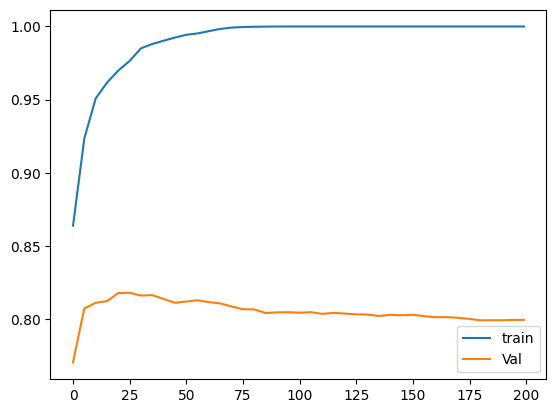

In [ ]:
plt.plot(df_score.num_iter,df_score.train_auc,label='train')
plt.plot(df_score.num_iter,df_score.val_auc,label='Val')
plt.legend()

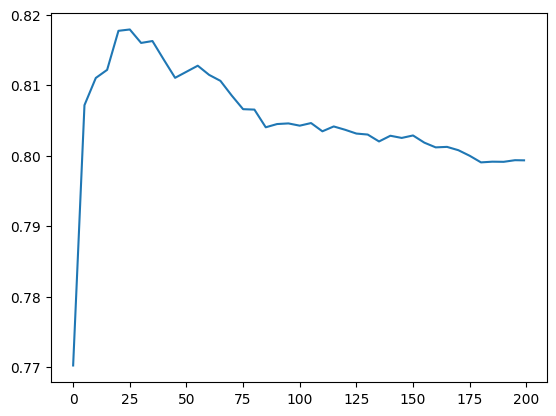

In [ ]:
plt.plot(df_score.num_iter,df_score.val_auc,label='Val')

# XGBoost parameter tuning

In [ ]:
scores={}

In [ ]:
%%capture output

import pandas as pd
import xgboost as xgb

scores = {}

for eta  in [1,0.01,0.1,10]:

    xgb_params = {
        'eta': eta,
        'max_depth': 3,
        'min_child_weight':3,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }

    evals_result = {}   # ⭐ REQUIRED

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=200,
        evals=watchlist,
        verbose_eval=False,
        evals_result=evals_result   # ⭐ saves history
    )

    # convert results to dataframe
    df_scores = pd.DataFrame(evals_result['val'])
    df_scores['num_iter'] = range(len(df_scores))

    scores[eta] = df_scores

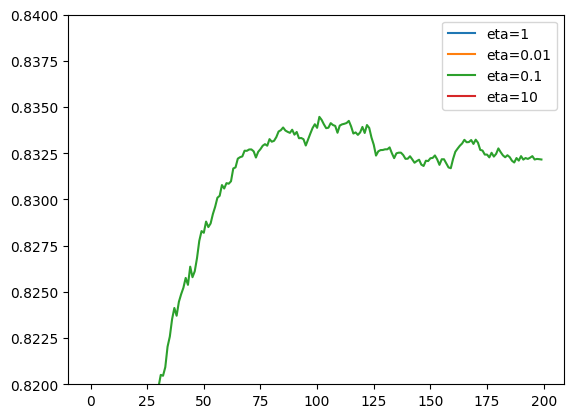

In [ ]:
import matplotlib.pyplot as plt

for eta, df_score in scores.items():
    plt.plot(df_score.num_iter,
             df_score.auc,
             label=f'eta={eta}')

plt.ylim(0.82, 0.84)
plt.legend()
plt.show()

In [ ]:

key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.01'

In [ ]:

scores = {}

In [ ]:

%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 10,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [ ]:

key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=10'

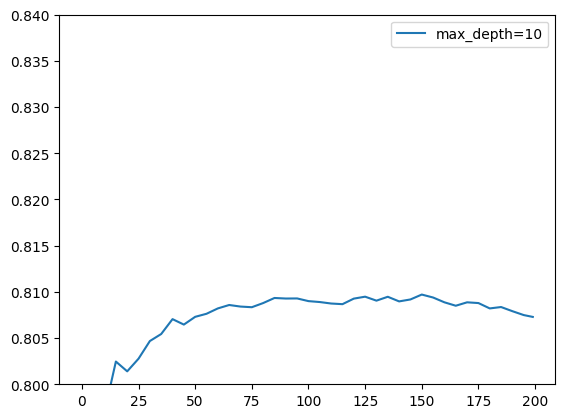

In [ ]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.ylim(0.8, 0.84)
plt.legend()

In [ ]:
df_scores

,auc,num_iter
0,0.764549,0
1,0.771560,1
2,0.774200,2
3,0.776340,3
4,0.781835,4
...,...,...
195,0.829984,195
196,0.830123,196
197,0.830178,197
198,0.829990,198


In [ ]:
%%capture output

import pandas as pd
import xgboost as xgb

scores = {}

for min_child_weight in [6, 3, 5, 4]:

    xgb_params = {
        'eta': 0.1,
        'max_depth': 3,
        'min_child_weight': min_child_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }

    evals_result = {}   # ⭐ REQUIRED

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=200,
        evals=watchlist,
        verbose_eval=False,
        evals_result=evals_result   # ⭐ saves history
    )

    # convert results to dataframe
    df_scores = pd.DataFrame(evals_result['val'])
    df_scores['num_iter'] = range(len(df_scores))

    scores[min_child_weight] = df_scores

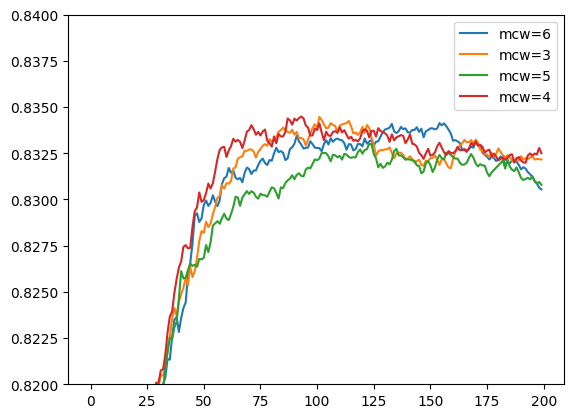

In [ ]:
import matplotlib.pyplot as plt

for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter,
             df_score.auc,
             label=f'mcw={min_child_weight}')

plt.ylim(0.82, 0.84)
plt.legend()
plt.show()

mcw=3

In [ ]:
%%capture output

import pandas as pd
import xgboost as xgb

scores_eta = {}

for eta in [0.01, 0.05, 0.1, 0.3]:

    xgb_params = {
        'eta': eta,
        'max_depth': 3,
        'min_child_weight': 1,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }

    evals_result = {}

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=200,
        evals=watchlist,
        verbose_eval=False,
        evals_result=evals_result
    )

    df_scores = pd.DataFrame(evals_result['val'])
    df_scores['num_iter'] = range(len(df_scores))

    scores_eta[eta] = df_scores

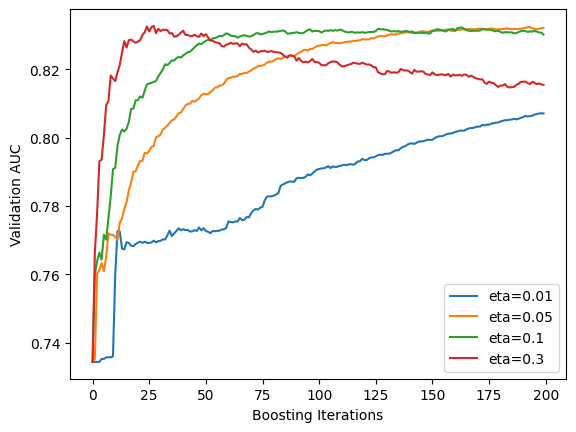

In [ ]:
import matplotlib.pyplot as plt

for eta, df_score in scores_eta.items():
    plt.plot(df_score.num_iter,
             df_score.auc,
             label=f'eta={eta}')

plt.xlabel("Boosting Iterations")
plt.ylabel("Validation AUC")
plt.legend()
plt.show()

eta=0.1

In [ ]:
%%capture output

scores_depth = {}

for max_depth in [2, 3, 4, 6, 8]:

    xgb_params = {
        'eta': 0.1,
        'max_depth': max_depth,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 8,
        'seed': 1,
        'verbosity': 1,
    }

    evals_result = {}

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=200,
        evals=watchlist,
        verbose_eval=False,
        evals_result=evals_result
    )

    df_scores = pd.DataFrame(evals_result['val'])
    df_scores['num_iter'] = range(len(df_scores))

    scores_depth[max_depth] = df_scores

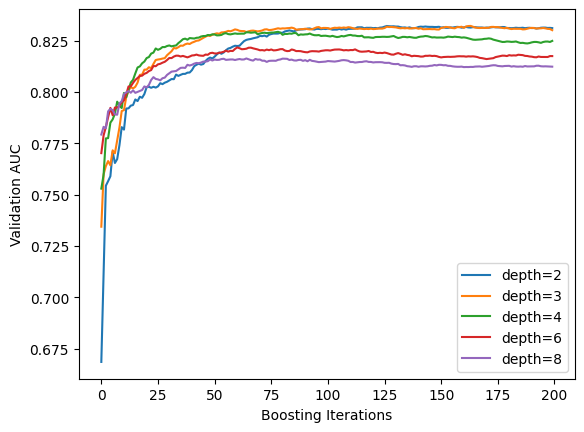

In [ ]:
for max_depth, df_score in scores_depth.items():
    plt.plot(df_score.num_iter,
             df_score.auc,
             label=f'depth={max_depth}')

plt.xlabel("Boosting Iterations")
plt.ylabel("Validation AUC")
plt.legend()
plt.show()

max_depth=4

In [ ]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 4,
    'min_child_weight':3,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

#choosing between the model

In [ ]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

In [ ]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.7738217771427187)

In [ ]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_estimators=200,
                       random_state=1)

In [ ]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.8245471168051148)

In [ ]:
xgb_params = {
    'eta': 0.1,
    'max_depth':3,
    'min_child_weight':1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

In [ ]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

np.float64(0.8316128211959023)

In [ ]:
df_full_train = df_full_train.reset_index(drop=True)

In [ ]:
y_full_train = (df_full_train.status == 'default').astype(int).values
y_full_train

array([0, 1, 0, ..., 0, 0, 1])

In [ ]:
del df_full_train['status']

In [ ]:

dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [ ]:
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train,
                    feature_names=list(dv.get_feature_names_out()))

dtest = xgb.DMatrix(X_test, feature_names=list(dv.get_feature_names_out()))

In [ ]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=175)

In [ ]:
y_pred = model.predict(dtest)

In [ ]:
y_pred_test = model.predict(dtest)
auc_test = roc_auc_score(y_test, y_pred_test)
print(f'Test AUC: {auc_test:.4f}')

Test AUC: 0.8284
